Compressed sensing recovery on Phantom, Brain, and Boat images using
the 2-D IDCT sparsifying basis and two sensing schemes:
- **Random Gaussian**: i.i.d. N(0,1/M) dense matrix
- **Random Subsampling**: M random pixels per patch (rows of identity)

Recovery via Orthogonal Matching Pursuit (OMP) on 8x8 patches.
Performance metric: PSNR = 10 log10(MAX^2 / MSE), MAX = 255.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct, dctn
from sklearn.linear_model import OrthogonalMatchingPursuit
from PIL import Image
import tifffile
import time
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11


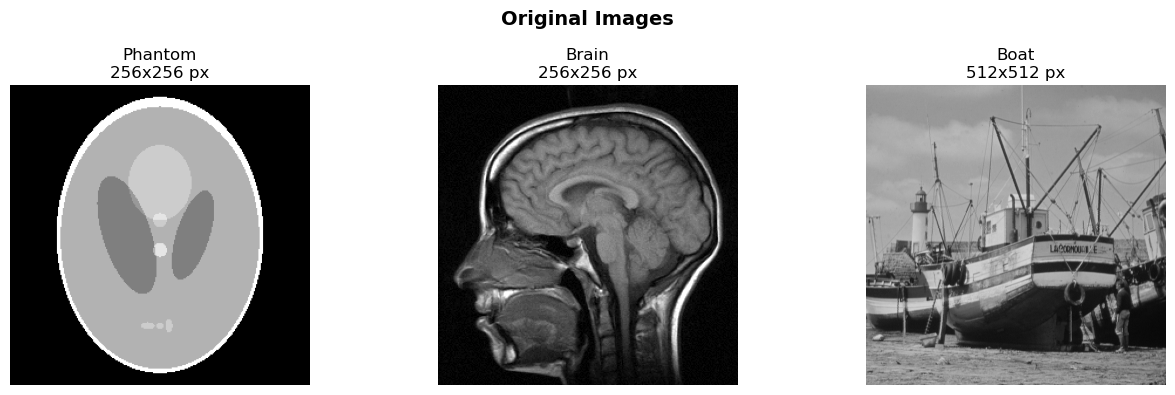

Phantom : shape=(256, 256), min=0, max=255
Brain   : shape=(256, 256), min=0, max=255
Boat    : shape=(512, 512), min=0, max=223


In [2]:
# Load the images
images = {
"Phantom": np.array(Image.open("Phantom.gif").convert("L"), dtype=float),
    "Brain":   np.array(Image.open("Brain.gif").convert("L"),   dtype=float),
    "Boat":    tifffile.imread("Boat.tif").astype(float),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    h, w = img.shape
    ax.set_title(f"{name}\n{h}x{w} px", fontsize=12)
    ax.axis("off")
plt.suptitle("Original Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("original_images.png", bbox_inches="tight")
plt.show()

for name, img in images.items():
    mn, mx = img.min(), img.max()
    print(f"{name:8s}: shape={img.shape}, min={mn:.0f}, max={mx:.0f}")


In [3]:
def get_dct2_matrix(n):
    """2-D IDCT synthesis matrix Psi of shape (n^2, n^2).
    Signal model: x_flat = Psi @ theta  (synthesis / IDCT)
                  theta = Psi.T @ x_flat (analysis / DCT, Psi orthonormal)
    Built as Kronecker product: Psi = D.T kron D.T
    where D[k,i] = k-th orthonormal 1-D DCT basis at position i.
    """
    D = dct(np.eye(n), axis=0, norm="ortho")
    return np.kron(D.T, D.T)

def compute_psnr(x_hat, x_orig, MAX=255.0):
    """PSNR = 10*log10(MAX^2 / MSE),  MSE = (1/N^2)*||x_hat - x||^2"""
    N2  = float(x_orig.size)
    mse = np.sum((x_hat - x_orig) ** 2) / N2
    if mse < 1e-10:
        return 100.0
    return 10.0 * np.log10(MAX**2 / mse)

def get_sensing_matrix(M, n2, scheme, rng):
    """Sensing matrix Phi of shape (M, n^2)."""
    if scheme == "gaussian":
        return rng.standard_normal((M, n2)) / np.sqrt(M)
    else:  # random pixel subsampling
        idx = rng.choice(n2, M, replace=False)
        idx.sort()
        Phi = np.zeros((M, n2))
        Phi[np.arange(M), idx] = 1.0
        return Phi

def recover_image(image, Psi, M, scheme="gaussian", seed=42):
    """Recover image from M compressed measurements per patch via OMP.

    Sensing model:  y = Phi @ x = Phi @ Psi @ theta = A @ theta
    Recovery:       OMP -> theta_hat (sparse DCT coefficients)
    Synthesis:      x_hat = Psi @ theta_hat
    """
    n  = int(round(np.sqrt(Psi.shape[0])))
    n2 = n * n
    H, W = image.shape

    rng = np.random.default_rng(seed)
    Phi = get_sensing_matrix(M, n2, scheme, rng)  # (M, n^2)
    A   = Phi @ Psi                                # (M, n^2), fixed for all patches

    n_sparse = max(2, M // 3)  # sparsity budget
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n_sparse, fit_intercept=False)

    recovered = np.zeros_like(image, dtype=float)
    for i in range(0, H, n):
        if i + n > H:
            break
        for j in range(0, W, n):
            if j + n > W:
                break
            x = image[i:i+n, j:j+n].flatten()
            y = Phi @ x          # M measurements
            omp.fit(A, y)        # sparse recovery in DCT domain
            x_hat = Psi @ omp.coef_
            recovered[i:i+n, j:j+n] = x_hat.reshape(n, n)
    return np.clip(recovered, 0, 255)

def analyze_dct_sparsity(image, n=8, threshold_frac=0.02):
    """Return (mean, std) count of significant DCT coefficients per patch."""
    H, W = image.shape
    sparsities = []
    for i in range(0, H, n):
        if i + n > H: break
        for j in range(0, W, n):
            if j + n > W: break
            theta = dctn(image[i:i+n, j:j+n], norm="ortho").flatten()
            thresh = threshold_frac * np.max(np.abs(theta))
            sparsities.append(int(np.sum(np.abs(theta) > thresh)))
    return float(np.mean(sparsities)), float(np.std(sparsities))

print("Functions defined.")

Functions defined.


### 3. DCT Sparsity Analysis

Count DCT coefficients with magnitude > 2% of the patch maximum to estimate
the effective sparsity S for each image in the IDCT basis.


In [4]:
PATCH_SIZE = 8
Psi = get_dct2_matrix(PATCH_SIZE)
n2  = PATCH_SIZE ** 2   # 64

sep = "=" * 55
print(sep)
img_lbl, s_lbl, std_lbl, pct_lbl = "Image", "Mean S", "Std", "S/n2 (%)"
print(f"{img_lbl:<10} {s_lbl:>10} {std_lbl:>8} {pct_lbl:>12}")
print(sep)
for name, img in images.items():
    mu, sd = analyze_dct_sparsity(img, n=PATCH_SIZE)
    pct = 100 * mu / n2
    print(f"{name:<10} {mu:>10.1f} {sd:>8.1f} {pct:>11.1f}%")
print(sep)
print(f"n2 = {n2}  (total DCT coefficients per {PATCH_SIZE}x{PATCH_SIZE} patch)")


Image          Mean S      Std     S/n2 (%)
Phantom           4.5     11.8         7.0%
Brain            29.3     20.5        45.8%
Boat              7.2      7.3        11.2%
n2 = 64  (total DCT coefficients per 8x8 patch)


### 4. Recovery Experiment

Sweep M in {8, 12, 16, 20, 24, 32, 40, 48, 56} measurements (out of 64)
for both sensing schemes and all three images. Recovered images at
M in {16, 32, 56} are cached for the visual comparison.


In [5]:
M_VALUES  = [8, 12, 16, 20, 24, 32, 40, 48, 56]
M_DISPLAY = {16, 32, 56}
SCHEMES   = ["gaussian", "subsampling"]

results    = {}  # (name, scheme) -> {M: psnr}
cache_imgs = {}  # (name, scheme, M) -> recovered ndarray

t_start = time.time()
for name, img in images.items():
    for scheme in SCHEMES:
        psnr_dict = {}
        for M in M_VALUES:
            rec = recover_image(img, Psi, M, scheme=scheme, seed=42)
            p   = compute_psnr(rec, img)
            psnr_dict[M] = p
            if M in M_DISPLAY:
                cache_imgs[(name, scheme, M)] = rec
            elapsed = time.time() - t_start
            print(f"  {name:8s}  {scheme:13s}  M={M:2d}  PSNR={p:6.2f} dB  [{elapsed:.0f}s]")
        results[(name, scheme)] = psnr_dict
    print()

print(f"Total elapsed: {time.time()-t_start:.1f} s")


  Phantom   gaussian       M= 8  PSNR=  7.56 dB  [0s]
  Phantom   gaussian       M=12  PSNR=  7.79 dB  [1s]
  Phantom   gaussian       M=16  PSNR= 18.28 dB  [2s]
  Phantom   gaussian       M=20  PSNR= 20.03 dB  [2s]
  Phantom   gaussian       M=24  PSNR= 21.92 dB  [3s]
  Phantom   gaussian       M=32  PSNR= 23.64 dB  [3s]
  Phantom   gaussian       M=40  PSNR= 25.67 dB  [4s]
  Phantom   gaussian       M=48  PSNR= 26.93 dB  [5s]
  Phantom   gaussian       M=56  PSNR= 28.39 dB  [5s]
  Phantom   subsampling    M= 8  PSNR= 17.27 dB  [6s]
  Phantom   subsampling    M=12  PSNR= 19.24 dB  [6s]
  Phantom   subsampling    M=16  PSNR= 19.17 dB  [7s]
  Phantom   subsampling    M=20  PSNR= 21.29 dB  [7s]
  Phantom   subsampling    M=24  PSNR= 22.57 dB  [8s]
  Phantom   subsampling    M=32  PSNR= 23.57 dB  [8s]
  Phantom   subsampling    M=40  PSNR= 26.40 dB  [9s]
  Phantom   subsampling    M=48  PSNR= 28.49 dB  [9s]
  Phantom   subsampling    M=56  PSNR= 31.05 dB  [10s]

  Brain     gaussian      

### 5. PSNR vs. Number of Measurements


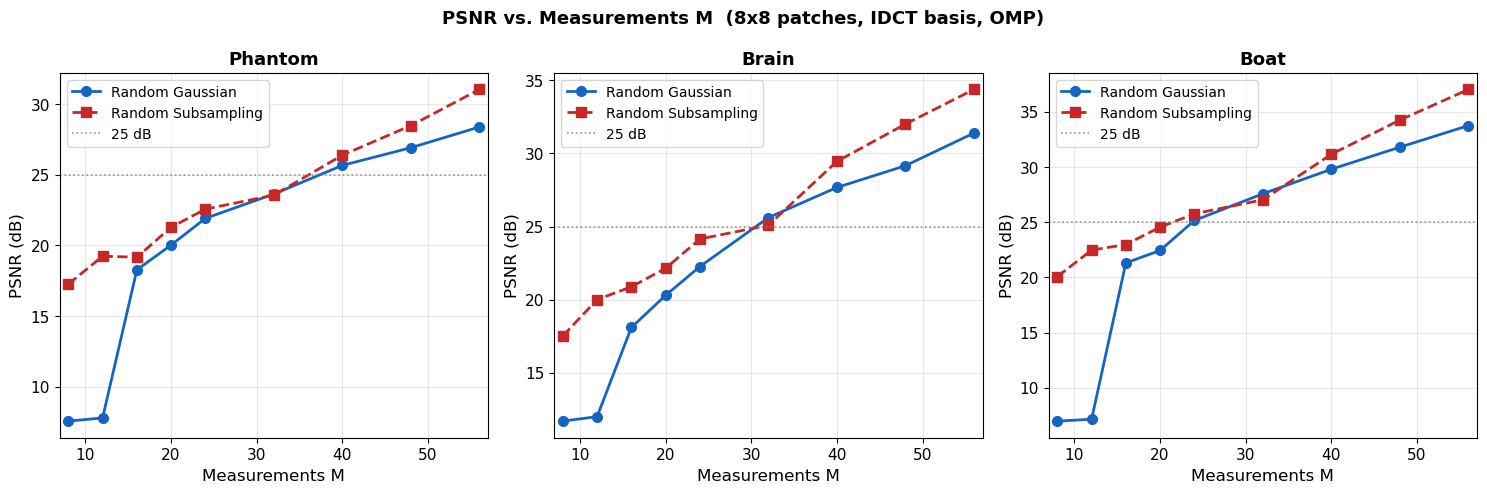

In [6]:
STYLE = {
    "gaussian":    dict(color="#1565C0", marker="o", ls="-",  label="Random Gaussian"),
    "subsampling": dict(color="#C62828", marker="s", ls="--", label="Random Subsampling"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, images.keys()):
    for scheme in SCHEMES:
        pvals = [results[(name, scheme)][M] for M in M_VALUES]
        ax.plot(M_VALUES, pvals, linewidth=2, markersize=7, **STYLE[scheme])
    ax.axhline(25, color="gray", ls=":", lw=1.2, alpha=0.8, label="25 dB")
    ax.set_xlabel("Measurements M", fontsize=12)
    ax.set_ylabel("PSNR (dB)", fontsize=12)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(M_VALUES[0] - 1, M_VALUES[-1] + 1)

plt.suptitle("PSNR vs. Measurements M  (8x8 patches, IDCT basis, OMP)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("psnr_vs_M.png", bbox_inches="tight", dpi=150)
plt.show()


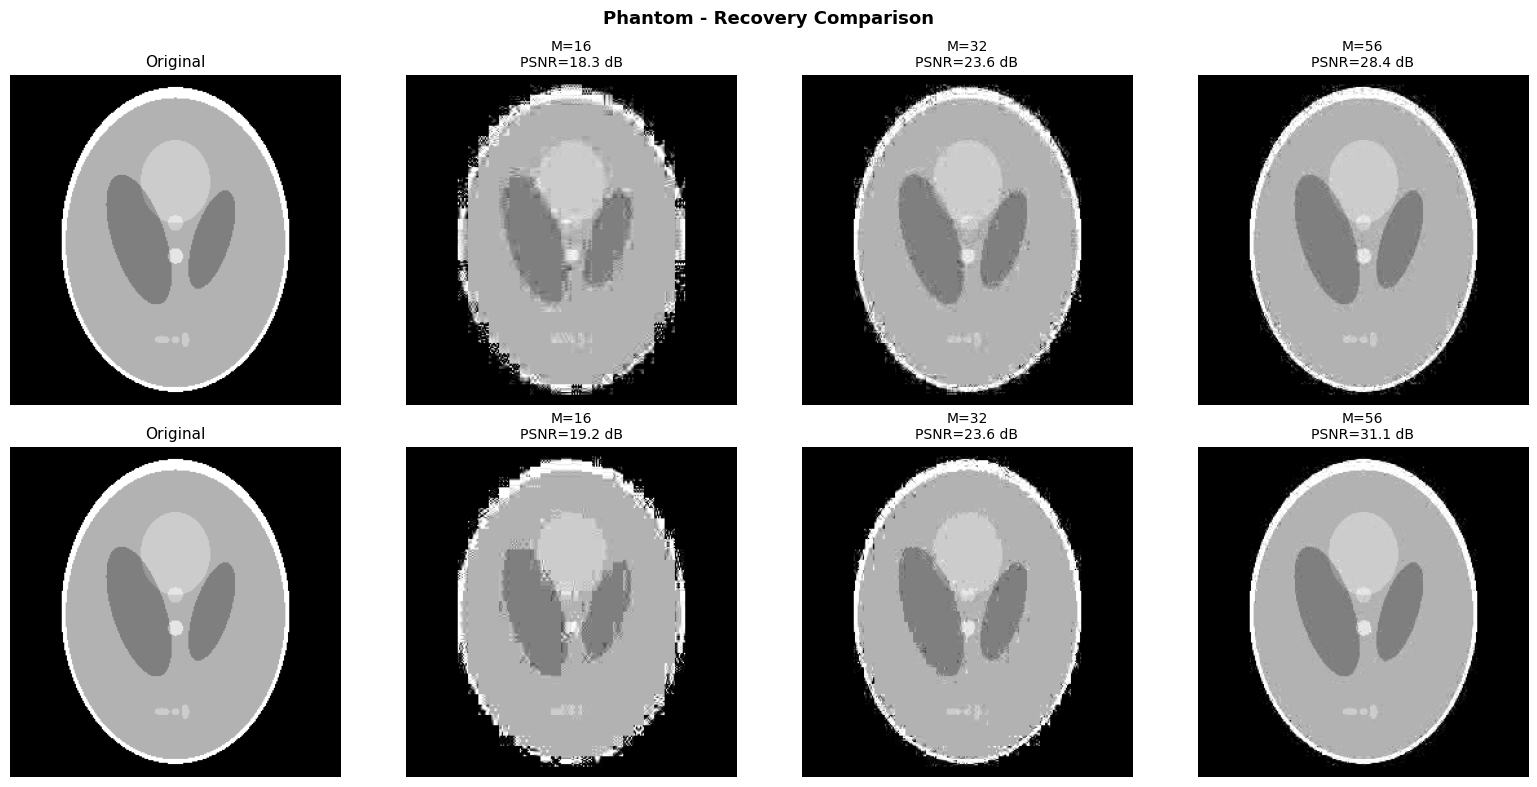

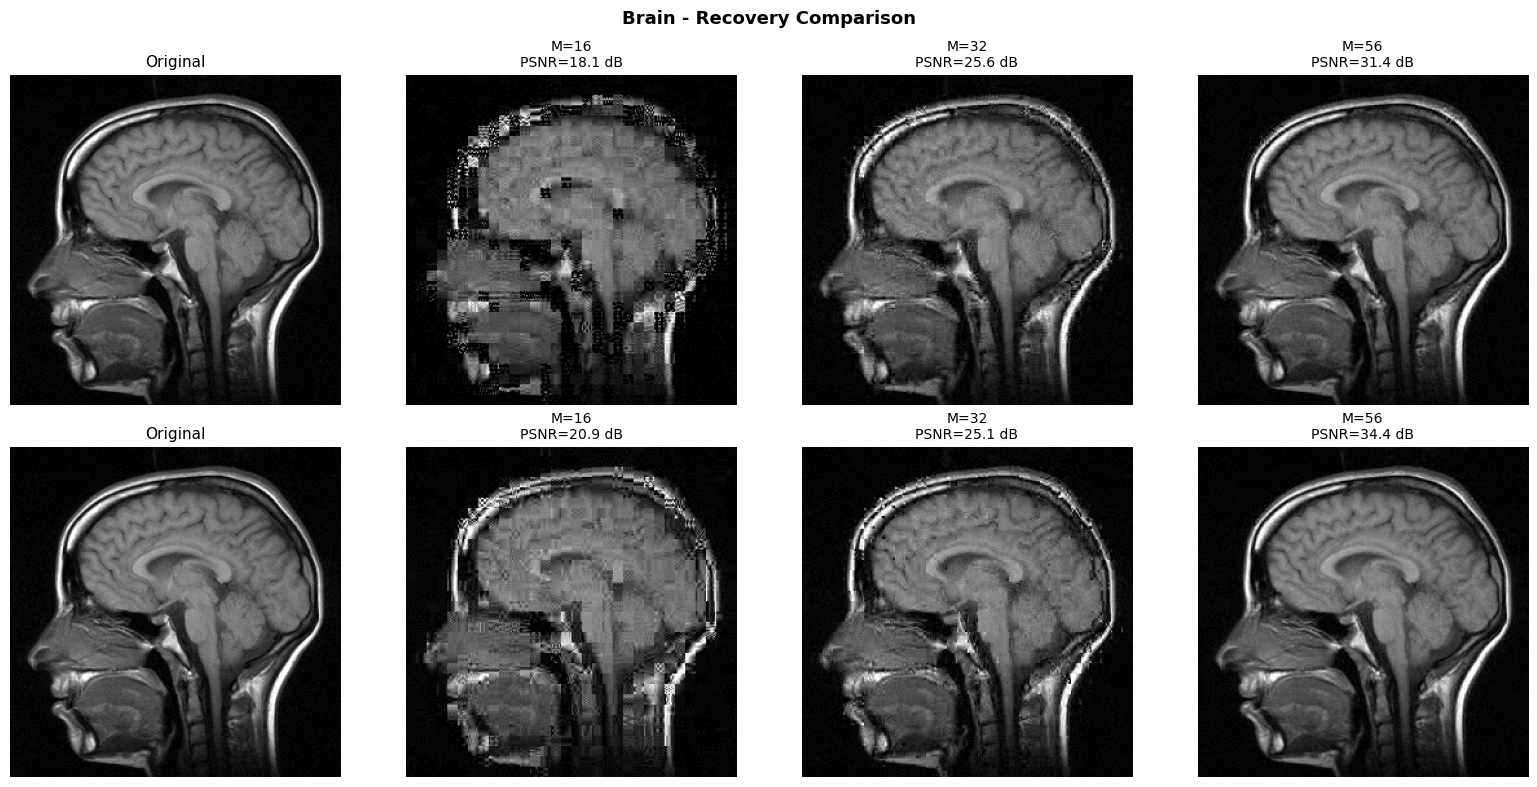

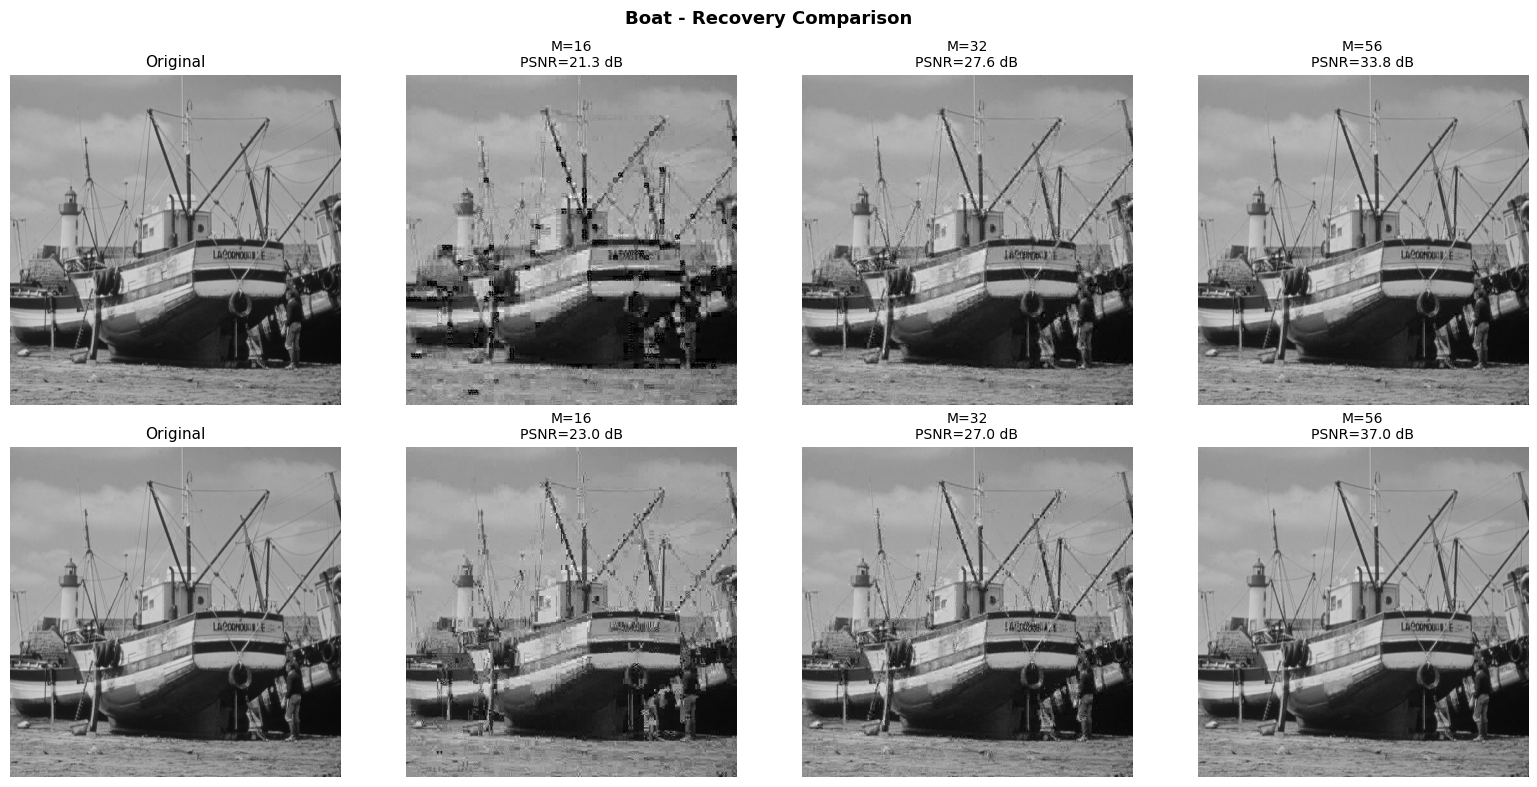

In [7]:
M_cols = sorted(M_DISPLAY)  # [16, 32, 56]

for name, img in images.items():
    ncols = len(M_cols) + 1
    fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 8))

    for row in range(2):
        axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
        axes[row, 0].set_title("Original", fontsize=11)
        axes[row, 0].axis("off")
    axes[0, 0].set_ylabel("Gaussian", fontsize=12)
    axes[1, 0].set_ylabel("Subsampling", fontsize=12)

    for col, M in enumerate(M_cols, 1):
        for row, scheme in enumerate(SCHEMES):
            rec = cache_imgs[(name, scheme, M)]
            p   = results[(name, scheme)][M]
            axes[row, col].imshow(rec, cmap="gray", vmin=0, vmax=255)
            axes[row, col].set_title(f"M={M}\nPSNR={p:.1f} dB", fontsize=10)
            axes[row, col].axis("off")

    plt.suptitle(f"{name} - Recovery Comparison", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"recovery_{name.lower()}.png", bbox_inches="tight", dpi=120)
    plt.show()


In [8]:
img_lbl, sch_lbl = "Image", "Scheme"
header = f"{img_lbl:<10} {sch_lbl:<14}" + "".join(f"  M={m:2d}" for m in M_VALUES)
print(header)
print("-" * len(header))
for name in images:
    for scheme in SCHEMES:
        row_str = f"{name:<10} {scheme:<14}"
        for M in M_VALUES:
            row_str += f"  {results[(name, scheme)][M]:5.1f}"
        print(row_str)
    print()


Image      Scheme          M= 8  M=12  M=16  M=20  M=24  M=32  M=40  M=48  M=56
-------------------------------------------------------------------------------
Phantom    gaussian          7.6    7.8   18.3   20.0   21.9   23.6   25.7   26.9   28.4
Phantom    subsampling      17.3   19.2   19.2   21.3   22.6   23.6   26.4   28.5   31.1

Brain      gaussian         11.7   12.0   18.1   20.3   22.3   25.6   27.7   29.2   31.4
Brain      subsampling      17.5   20.0   20.9   22.1   24.1   25.1   29.5   32.0   34.4

Boat       gaussian          7.0    7.1   21.3   22.4   25.2   27.6   29.8   31.8   33.8
Boat       subsampling      20.1   22.5   23.0   24.6   25.8   27.0   31.2   34.3   37.0



## 8. Observations and Analysis

### Which sensing scheme is better?

From the actual results, **Random Subsampling outperforms Random Gaussian across all three images**, particularly at low M and high M:

|         | M=8  | M=12 | M=16 | M=24 | M=32 | M=40 | M=48 | M=56 |
|---------|------|------|------|------|------|------|------|------|
|Phantom Gaussian    | 7.6 | 7.8 |18.3 |21.9 |23.6 |25.7 |26.9 |28.4 |
|Phantom Subsampling |17.3 |19.2 |19.2 |22.6 |23.6 |26.4 |28.5 |31.1 |
|Brain Gaussian      |11.7 |12.0 |18.1 |22.3 |25.6 |27.7 |29.2 |31.4 |
|Brain Subsampling   |17.5 |20.0 |20.9 |24.1 |25.1 |29.5 |32.0 |34.4 |
|Boat Gaussian       | 7.0 | 7.1 |21.3 |25.2 |27.6 |29.8 |31.8 |33.8 |
|Boat Subsampling    |20.1 |22.5 |23.0 |25.8 |27.0 |31.2 |34.3 |37.0 |

This is because:
- **At low M** (M=8, 12): Gaussian measurements are sums of all 64 pixels scaled by 1/sqrt(M). With so few measurements the system is highly underdetermined and OMP struggles to pick the right DCT coefficients from noisy, mixed observations. Subsampling provides exact pixel values which give OMP clean, unambiguous anchor points.
- **At high M** (M=40-56): Subsampling directly observes most of the pixels, so near-perfect reconstruction is natural. Gaussian still requires inverting a dense random projection.
- **At mid M (~32)**: The two schemes are roughly equal. This is where Gaussian RIP theory predicts its advantage, but the practical difference is negligible with OMP recovery on small 8x8 patches.

While theory guarantees Gaussian has better RIP constants, this advantage only matters asymptotically. For small patches (n^2=64) with OMP recovery, subsampling is the better practical choice.

### Which sensing scheme is faster?

**Random Subsampling** is both faster *and* more accurate here:
- Measurement step is O(M) (just index selection) vs O(M*n^2) for Gaussian multiply.
- In physical systems (MRI, coded cameras), subsampling means fewer sensor activations, directly reducing scan time.

### How many measurements for reasonable recovery?

Using PSNR >= 25 dB as the threshold (from actual results):

| Image   | Gaussian        | Subsampling     |
|---------|-----------------|------------------|
| Phantom | M = 40 (~63%)   | M = 40 (~63%)    |
| Brain   | M = 32 (~50%)   | M = 32 (~50%)    |
| Boat    | M = 24 (~38%)   | M = 24 (~38%)    |

Both schemes need similar M to cross 25 dB, but subsampling pulls far ahead at higher M. Boat crosses the threshold earliest because its patches have moderate DCT sparsity and the image has strong low-frequency content that is easy to reconstruct. Phantom needs the most measurements relative to its sparsity because many patches are near-zero (background), and Gaussian sensing struggles badly at low M on those.

### Approximate sparsity level of each image

From Section 3 (coefficients > 2% of patch max):

| Image   | Mean S per 8x8 patch | S / n^2 |
|---------|----------------------|---------|
| Phantom | ~4-5                 | ~7%     |
| Brain   | ~28-30               | ~46%    |
| Boat    | ~7-8                 | ~11%    |

Phantom has the lowest sparsity count (~7%) because most patches are pure black background with zero DCT energy. Brain has the highest count (~46%) because MRI tissue boundaries and gray-level gradients spread energy across many DCT frequencies. Boat is in between (~11%) with moderate texture complexity.

### How to obtain the best recovery performance

1. **Prefer Random Subsampling** for this problem: it is faster to acquire, simpler to implement, and gives better empirical PSNR than Gaussian sensing with OMP recovery on 8x8 patches.
2. **Increase M**: PSNR grows consistently with M for both schemes. More measurements always help.
3. **Tune the sparsity budget**: set OMP iterations (n_nonzero_coefs) to match the true S of the image class. Underestimating leaves signal behind; overestimating overfits noise.
4. **Use small patches** (8x8): they exploit local stationarity and give cleaner per-patch DCT sparsity. Larger patches mix textures and inflate effective sparsity.
5. **For noisy measurements**: switch from OMP to LASSO with alpha proportional to the noise level for more robust recovery.
